# California Housing Prices Project


# Global Imports & Environment Configurations

In [ ]:
!pip install streamlit

In [ ]:
# 1 Data Manipulation:
import pandas as pd
import numpy as np
# 2 Preprocessing
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
# 3 Statistical Analysis
from scipy import stats
from scipy.spatial.distance import mahalanobis
# 4 Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# 5 Dashboarding
import streamlit as st
# Environment Configurations
%matplotlib inline
sns.set_theme(style="whitegrid")

In [ ]:
# Unified color palette
PRIMARY_COLOR     = '#4C72B0'
SECONDARY_COLOR   = '#C44E52'
CATEGORICAL_PALETTE = 'viridis'
CONTINUOUS_CMAP   = 'coolwarm'

# Part 1: Introduction & Setup

In [ ]:
# 1 Load the dataset and convert it into a pandas DataFrame
california_dataset = fetch_california_housing(as_frame=True)
df = california_dataset.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
# 2 Report: shape
print(df.shape)

(20640, 9)


In [ ]:
# 2 Report: feature names
print(df.columns.tolist())

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


In [ ]:
# 2 Report: description of the target variable (MedHouseValue)
print(california_dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [ ]:
# 3 hypotheses

# Median income is positively associated with median house value.

# House values differ significantly across income quartiles.

# Geographical location influences house values across California districts.

# Part 2: Data Preprocessing

In [ ]:
# 4 Check data types and ensure all columns are numerical
print(df.dtypes)

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object


In [ ]:
# 5 Scale all features using StandardScaler
features_only = df.drop('MedHouseVal', axis=1)
target_values = df['MedHouseVal']

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features_only)

df_scaled = pd.DataFrame(scaled_data, columns=features_only.columns)
df_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


In [ ]:
# 6 Create new features
df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']
df['PopulationDensity'] = df['Population'] / df['AveOccup']
df['IncomePerPerson'] = df['MedInc'] / df['AveOccup']
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomsPerRoom,PopulationDensity,IncomePerPerson
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,126.0,3.257687
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1138.0,3.934608
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,177.0,2.589838
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154,0.184458,219.0,2.214765
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646,0.172096,259.0,1.763125


In [ ]:
# scale the new features
new_cols = ['RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationDensity', 'IncomePerPerson']

scaler_new = StandardScaler()
scaled_new_data = scaler_new.fit_transform(df[new_cols])

df_new_scaled = pd.DataFrame(scaled_new_data, columns=new_cols)
df_scaled = pd.concat([df_scaled, df_new_scaled], axis=1)

df_scaled['MedHouseVal'] = target_values.values
df_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerHousehold,BedroomsPerRoom,PopulationDensity,IncomePerPerson,MedHouseVal
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,0.659647,-1.145833,-0.977033,2.449492,4.526
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,0.854906,-0.987175,1.669961,3.346077,3.585
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,0.855758,-1.440115,-0.843637,1.564922,3.521
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,0.267179,-0.493194,-0.733781,1.068136,3.413
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,0.787681,-0.706259,-0.629157,0.469937,3.422


# Part 3: Data Cleaning

In [ ]:
# 7 Randomly introduce 5% missing values in HouseAge. Show the missingness clearly
df_clean = df.copy()
np.random.seed(10)

n_missing = int(len(df_clean) * 0.05)
missing_indices = np.random.choice(df_clean.index, n_missing, replace=False)
df_clean.loc[missing_indices, 'HouseAge'] = np.nan

missing_count = df_clean['HouseAge'].isnull().sum()
print("Missing value counts: ",missing_count)

missing_percentage = (missing_count / len(df_clean)) * 100
print("Missig value percentage: ",missing_percentage)

df_clean[df_clean['HouseAge'].isnull()].head()

Missing value counts:  1032
Missig value percentage:  5.0


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomsPerRoom,PopulationDensity,IncomePerPerson
7,3.1200,NaN,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414,2.682800,0.221327,647.0,1.744719
16,2.7750,NaN,5.939577,1.048338,793.0,2.395770,37.85,-122.27,1.525,2.479193,0.176501,331.0,1.158291
39,2.5898,NaN,3.494253,1.027299,1377.0,1.978448,37.83,-122.26,1.760,1.766158,0.293997,696.0,1.309006
43,3.9643,NaN,4.797980,1.020202,467.0,2.358586,37.84,-122.26,1.888,2.034261,0.212632,198.0,1.680795
59,2.5625,NaN,2.771930,0.754386,94.0,1.649123,37.82,-122.29,0.600,1.680851,0.272152,57.0,1.553856


In [ ]:
# 8 Handle missing values with: Mean imputation
mean_value = df_clean['HouseAge'].mean()
df_mean_imputed = df_clean['HouseAge'].fillna(mean_value)

In [ ]:
# 8 Handle missing values with: Median imputation
median_value = df_clean['HouseAge'].median()
df_median_imputed = df_clean['HouseAge'].fillna(median_value)

In [ ]:
# 8 Compare results
comparison_table = pd.DataFrame({
    'Original': df['HouseAge'].describe().round(2),
    'After Mean Imputation': df_mean_imputed.describe().round(2),
    'After Median Imputation': df_median_imputed.describe().round(2)
})
display(comparison_table)

,Original,After Mean Imputation,After Median Imputation
count,20640.00,20640.00,20640.00
mean,28.64,28.64,28.65
std,12.59,12.27,12.27
min,1.00,1.00,1.00
25%,18.00,19.00,19.00
50%,29.00,28.64,29.00
75%,37.00,37.00,37.00
max,52.00,52.00,52.00


In [ ]:
df_clean['HouseAge'] = df_clean['HouseAge'].fillna(median_value)
remaining_nans = df_clean['HouseAge'].isnull().sum()
print("Missing value counts: ",remaining_nans)

Missing value counts:  0


In [ ]:
# 9 Introduce 10 artificial outliers in MedInc (multiply values by 20)
np.random.seed(15)

outlier_indices = np.random.choice(df_clean.index, 10, replace=False)
original_values = df_clean.loc[outlier_indices, 'MedInc'].copy()
df_clean.loc[outlier_indices, 'MedInc'] = df_clean.loc[outlier_indices, 'MedInc'] * 20

outliers_comparison = pd.DataFrame({
    'Original_Value': original_values,
    'Outlier_Value': df_clean.loc[outlier_indices, 'MedInc']
}, index=outlier_indices)
display(outliers_comparison)

,Original_Value,Outlier_Value
540,2.9688,59.376
343,1.9167,38.334
9103,3.8594,77.188
1277,6.9051,138.102
2726,1.6607,33.214
12883,3.0417,60.834
16405,3.3882,67.764
20310,2.7260,54.520
17243,2.7070,54.140
14651,3.1458,62.916


In [ ]:
# 9 Detect them using: Z-score method
z_scores = np.abs((df_clean['MedInc'] - df_clean['MedInc'].mean()) / df_clean['MedInc'].std())
z_outliers = df_clean[z_scores > 3]
print("Outlier counts: ",len(z_outliers))

check_all_detected = set(outlier_indices).issubset(set(z_outliers.index))
print("Check if introduced outlier detected: ",check_all_detected)

Outlier counts:  161
Check if introduced outlier detected:  True


In [ ]:
# 9 Detect them using: IQR method
Q1 = df_clean['MedInc'].quantile(0.25)   # 25%
Q3 = df_clean['MedInc'].quantile(0.75)   # 75%
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df_clean[(df_clean['MedInc'] < lower_bound) | (df_clean['MedInc'] > upper_bound)]
print("Outlier counts: ",len(iqr_outliers))

check_all_detected2 = set(outlier_indices).issubset(set(iqr_outliers.index))
print("Check if introduced outlier detected: ",check_all_detected2)

Outlier counts:  688
Check if introduced outlier detected:  True


In [ ]:
# 10 Remove or cap the outliers and explain your decision
df_clean.loc[outlier_indices, 'MedInc'] = np.clip(
    df_clean.loc[outlier_indices, 'MedInc'],
    lower_bound,
    upper_bound
)

print("Synthetic outliers capped: ", len(outlier_indices))
print("Remaining IQR outliers: ",
      len(df_clean[(df_clean['MedInc'] < lower_bound) | (df_clean['MedInc'] > upper_bound)]))

scaler_update = StandardScaler()
features_to_update = ['MedInc', 'HouseAge']
df_scaled[features_to_update] = scaler_update.fit_transform(df_clean[features_to_update])
df_scaled.head(10)

Synthetic outliers capped:  10
Remaining IQR outliers:  678


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,RoomsPerHousehold,BedroomsPerRoom,PopulationDensity,IncomePerPerson,MedHouseVal
0,2.341201,1.006048,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835,0.659647,-1.145833,-0.977033,2.449492,4.526
1,2.328685,-0.623838,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844,0.854906,-0.987175,1.669961,3.346077,3.585
2,1.779696,1.902486,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827,0.855758,-1.440115,-0.843637,1.564922,3.521
3,0.930814,1.902486,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818,0.267179,-0.493194,-0.733781,1.068136,3.413
4,-0.014088,1.902486,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818,0.787681,-0.706259,-0.629157,0.469937,3.422
5,0.086139,1.902486,-0.269730,0.014669,-0.894071,-0.089618,1.038503,-1.337818,0.216591,0.322276,-0.801787,0.633276,2.697
6,-0.112475,1.902486,-0.200918,-0.306633,-0.292712,-0.090725,1.033821,-1.337818,0.296874,-0.347714,0.037823,0.411724,2.992
7,-0.395961,0.028116,-0.255232,-0.073542,-0.237079,-0.123476,1.033821,-1.337818,0.615912,0.142236,0.385698,0.445557,2.414
8,-0.942637,1.087543,-0.458703,0.044254,-0.193810,-0.100499,1.033821,-1.342809,0.123565,0.813474,0.249687,-0.505860,2.267
9,-0.095595,1.902486,-0.185283,-0.224687,0.110844,-0.086501,1.033821,-1.337818,0.271583,-0.238934,0.560944,0.385316,2.611


# Part 4: Descriptive Statistics

In [ ]:
# 11 Compute mean, median, variance, skewness, and kurtosis for all features
features_df = df_clean.drop(columns=['MedHouseVal'])

mean_vals = features_df.mean()
median_vals = features_df.median()
variance_vals = features_df.var()
skewness_vals = features_df.skew()
kurtosis_vals = features_df.kurt()

descriptive_stats_table = pd.DataFrame({
    'Mean': mean_vals,
    'Median': median_vals,
    'Variance': variance_vals,
    'Skewness': skewness_vals,
    'Kurtosis': kurtosis_vals
})
display(descriptive_stats_table.round(4))

,Mean,Median,Variance,Skewness,Kurtosis
MedInc,3.8730,3.5364,3.616600e+00,1.6431,4.9232
HouseAge,28.6550,29.0000,1.505796e+02,0.0567,-0.6842
AveRooms,5.4290,5.2291,6.121500e+00,20.6979,879.3533
AveBedrms,1.0967,1.0488,2.246000e-01,31.3170,1636.7120
Population,1425.4767,1166.0000,1.282470e+06,4.9359,73.5531
AveOccup,3.0707,2.8181,1.078700e+02,97.6396,10651.0106
Latitude,35.6319,34.2600,4.562300e+00,0.4660,-1.1178
Longitude,-119.5697,-118.4900,4.014100e+00,-0.2978,-1.3302
RoomsPerHousehold,1.9770,1.9379,1.313400e+00,17.7751,600.6687
BedroomsPerRoom,0.2131,0.2032,3.400000e-03,2.2469,14.2807


In [ ]:
# 12 Identify which features are most skewed and which are approximately normal
most_skewed_feature = skewness_vals.abs().idxmax()
closest_to_normal_feature = skewness_vals.abs().idxmin()

print("Most skewed feature: ",most_skewed_feature)
print("Skewed value: ",skewness_vals[most_skewed_feature])

print("Approximately normal feauture: ",closest_to_normal_feature)
print("Skewed value: ",skewness_vals[closest_to_normal_feature])

Most skewed feature:  AveOccup
Skewed value:  97.63956096369479
Approximately normal feauture:  HouseAge
Skewed value:  0.05666012716236537


In [ ]:
# 13 Rank the features by variance. Which 3 vary the most across California?
ranked_variance = variance_vals.sort_values(ascending=False)

for rank, (col_name, var_value) in enumerate(ranked_variance.items(), 1):
    print(f"{rank}: {col_name} -> {var_value:.4f}")

top_3_variance = list(ranked_variance.index[:3])
print("Top 3 feature by variance: ",top_3_variance)

1: Population -> 1282470.4572
2: PopulationDensity -> 146176.0399
3: HouseAge -> 150.5796
4: AveOccup -> 107.8700
5: AveRooms -> 6.1215
6: Latitude -> 4.5623
7: Longitude -> 4.0141
8: MedInc -> 3.6166
9: RoomsPerHousehold -> 1.3134
10: IncomePerPerson -> 0.5701
11: AveBedrms -> 0.2246
12: BedroomsPerRoom -> 0.0034
Top 3 feature by variance:  ['Population', 'PopulationDensity', 'HouseAge']


In [ ]:
# 14 Which feature correlates most strongly with MedHouseValue?
correlation_matrix = df_clean.corr()
target_correlation = correlation_matrix['MedHouseVal'].drop('MedHouseVal')

sorted_correlations = target_correlation.abs().sort_values(ascending=False)
strongest_correlated_feature = sorted_correlations.index[0]
actual_correlation_val = target_correlation[strongest_correlated_feature]

print(target_correlation.round(4))
print("Strongest correlated feauture with MedHouseVal: ",strongest_correlated_feature)
print(f"Correlation value: {actual_correlation_val:.4f}")

MedInc               0.6867
HouseAge             0.1018
AveRooms             0.1519
AveBedrms           -0.0467
Population          -0.0246
AveOccup            -0.0237
Latitude            -0.1442
Longitude           -0.0460
RoomsPerHousehold    0.2095
BedroomsPerRoom     -0.2556
PopulationDensity    0.0658
IncomePerPerson      0.7456
Name: MedHouseVal, dtype: float64
Strongest correlated feauture with MedHouseVal:  IncomePerPerson
Correlation value: 0.7456


# Part 5: Advanced Data Exploration & Group Analysis

In [ ]:
# 15 Binning & Grouping: Bin HouseAge into 3 groups: Young (≤20), Middle (21–40), Old (>40)
df_clean["AgeGroup"] = pd.cut(
    df_clean["HouseAge"],
    bins=[0, 20, 40, float("inf")],
    labels=["Young", "Middle", "Old"]
)
df_clean["AgeGroup"].value_counts()

,count
AgeGroup,
Middle,10980
Young,5978
Old,3682


In [ ]:
# 15 Binning & Grouping: Compute mean and variance of MedHouseValue per group
age_summary = df_clean.groupby( "AgeGroup",observed=False)["MedHouseVal"].agg( ["mean", "var"])
age_summary

,mean,var
AgeGroup,,
Young,1.938788,1.047169
Middle,2.064455,1.338224
Old,2.291484,1.697384


In [ ]:
# 16 Income Segmentation: Create income quartiles based on MedInc
df_clean["IncomeQuartile"] = pd.qcut(
    df_clean["MedInc"],
    q=4,
    labels=["Q1", "Q2", "Q3", "Q4"]
)
df_clean["IncomeQuartile"].value_counts()

,count
IncomeQuartile,
Q1,5160
Q2,5160
Q3,5160
Q4,5160


In [ ]:
# 16 Income Segmentation: Compare average MedHouseValue, AveRooms, and Population across these quartiles
income_summary = df_clean.groupby(
    "IncomeQuartile",
    observed=False
)[
    ["MedHouseVal", "AveRooms", "Population"]
].mean()

In [ ]:
# 16 Income Segmentation: Present results in a summary table
income_summary.round(4)

,MedHouseVal,AveRooms,Population
IncomeQuartile,,,
Q1,1.2301,4.5677,1349.3851
Q2,1.7186,5.0320,1457.6025
Q3,2.1594,5.5451,1448.8174
Q4,3.1661,6.5712,1446.1019


In [ ]:
# 17 Geographical Analysis: Divide dataset into North vs. South California using the median of Latitude
median_latitude = df_clean["Latitude"].median()
print("Median Latitude:", median_latitude)

df_clean["Region"] = np.where(
    df_clean["Latitude"] >= median_latitude,
    "North",
    "South"
)
df_clean["Region"].value_counts()

Median Latitude: 34.26


,count
Region,
North,10327
South,10313


In [ ]:
# 17 Geographical Analysis: Compare median house values and average incomes between the two regions
region_summary = df_clean.groupby(
    "Region"
).agg({
    "MedHouseVal": "median",
    "MedInc": "mean"
})
region_summary.round(4)

,MedHouseVal,MedInc
Region,,
North,1.612,3.7651
South,1.907,3.9811


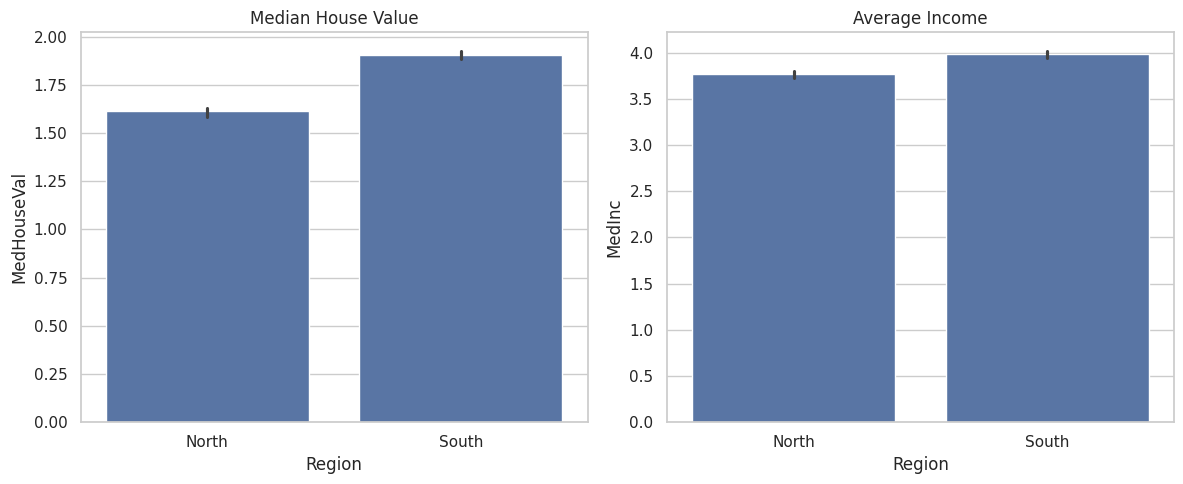

In [ ]:
# 17 Geographical Analysis: Plot side-by-side bar charts
fig, axes = plt.subplots(
    1, 2,
    figsize=(12,5)
)

sns.barplot(
    data=df_clean,
    x="Region",
    y="MedHouseVal",
    estimator=np.median,
    ax=axes[0]
)
axes[0].set_title("Median House Value")

sns.barplot(
    data=df_clean,
    x="Region",
    y="MedInc",
    estimator=np.mean,
    ax=axes[1]
)
axes[1].set_title("Average Income")

plt.tight_layout()
plt.show()

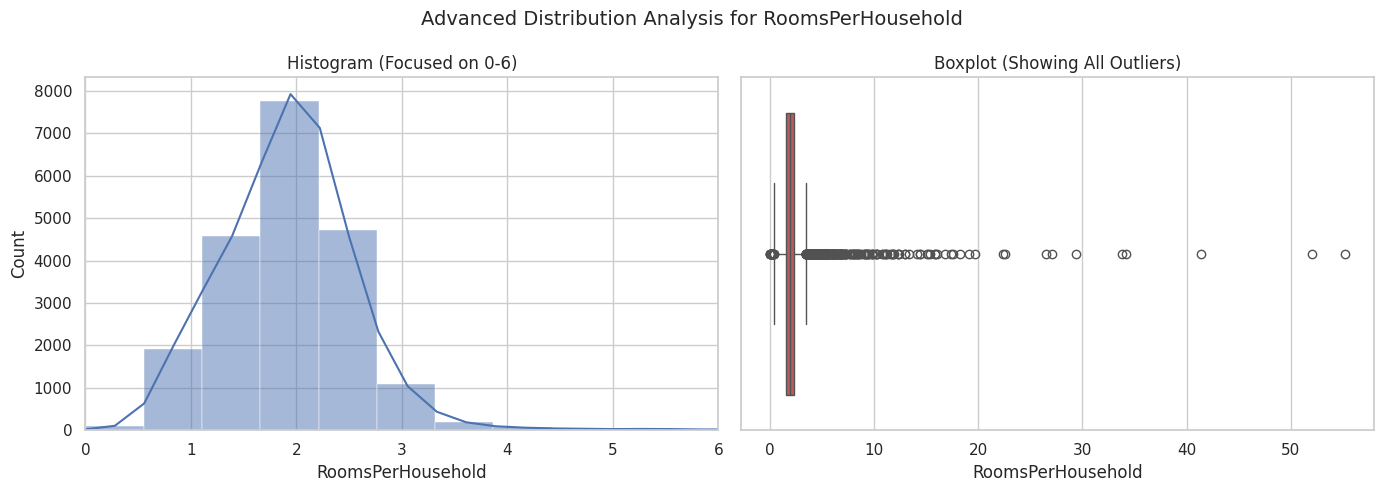

,RoomsPerHousehold
count,20640.000000
mean,1.976970
std,1.146020
min,0.002547
25%,1.522382
50%,1.937936
75%,2.296090
max,55.222222


In [ ]:
# 18.Feature Ratios & Insights: Analyze distributions of RoomsPerHousehold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["RoomsPerHousehold"], bins=100, kde=True, ax=axes[0], color=PRIMARY_COLOR)
axes[0].set_xlim(0, 6)
axes[0].set_title("Histogram (Focused on 0-6)")

sns.boxplot(x=df_clean["RoomsPerHousehold"], ax=axes[1], color=SECONDARY_COLOR)
axes[1].set_title("Boxplot (Showing All Outliers)")

plt.suptitle("Advanced Distribution Analysis for RoomsPerHousehold", fontsize=14)
plt.tight_layout()
plt.show()

df_clean["RoomsPerHousehold"].describe()

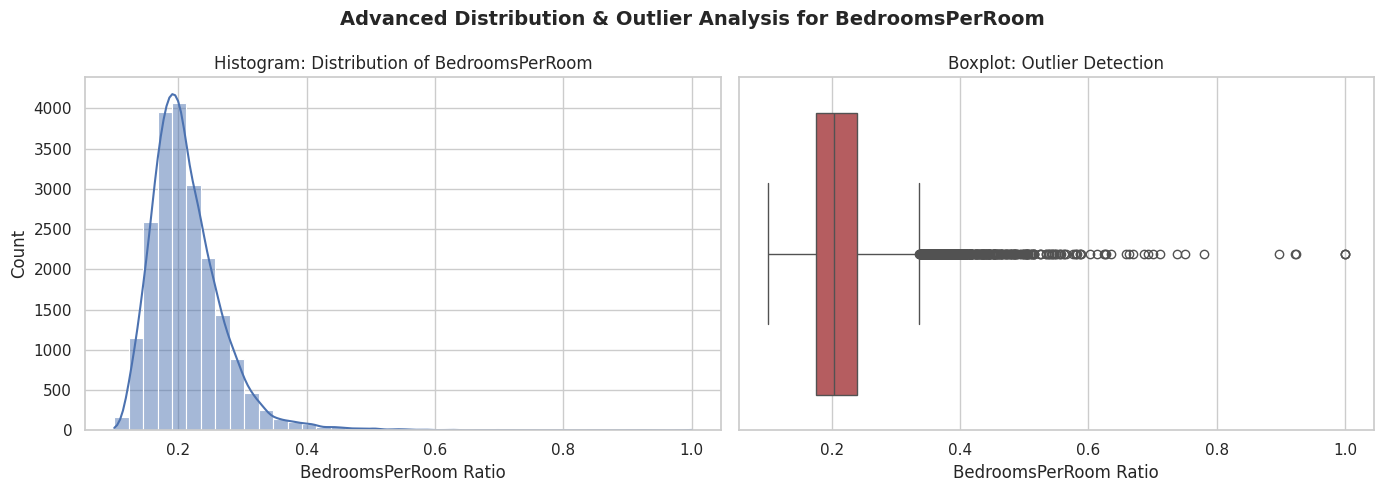

,BedroomsPerRoom
count,20640.000000
mean,0.213075
std,0.058023
min,0.100000
25%,0.175426
50%,0.203181
75%,0.239834
max,1.000000


In [ ]:
# 18.Feature Ratios & Insights: Analyze distributions of BedroomsPerRoom
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=df_clean,
    x="BedroomsPerRoom",
    bins=40,
    kde=True,
    ax=axes[0],
    color=PRIMARY_COLOR
)
axes[0].set_title("Histogram: Distribution of BedroomsPerRoom")
axes[0].set_xlabel("BedroomsPerRoom Ratio")

sns.boxplot(
    data=df_clean,
    x="BedroomsPerRoom",
    ax=axes[1],
    color=SECONDARY_COLOR
)
axes[1].set_title("Boxplot: Outlier Detection")
axes[1].set_xlabel("BedroomsPerRoom Ratio")

plt.suptitle("Advanced Distribution & Outlier Analysis for BedroomsPerRoom", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_clean["BedroomsPerRoom"].describe()

Interpretation of extreme ratio values:
- RoomsPerHousehold has a max of 55, far above the typical range (1.5–2.5). These extreme values
  correspond to districts with very low average occupancy (AveOccup near zero), meaning very few
  people live in housing blocks with relatively many rooms. Values near the minimum (0.002) indicate overcrowding instead.
- BedroomsPerRoom has a max of 1.0, meaning 100% of rooms in that district are bedrooms with no
  living/common space. Values near the minimum (0.10)
  indicate spacious housing with many non-bedroom rooms relative to bedrooms.

In [ ]:
# 19 Cross-tabulation: Create a cross-tab between HouseAge groups and Income quartiles with average MedHouseValue
cross_tab_result = df_clean.pivot_table(
    values='MedHouseVal',
    index='AgeGroup',
    columns='IncomeQuartile',
    aggfunc='mean',
    observed=False
)
display(cross_tab_result.round(4))

IncomeQuartile,Q1,Q2,Q3,Q4
AgeGroup,,,,
Young,1.1736,1.5057,1.8408,2.8075
Middle,1.2179,1.6946,2.1560,3.2568
Old,1.3148,2.0782,2.7364,3.8651


In [ ]:
# 19 Cross-tabulation: Interpret patterns: which combinations of house age + income produce the highest and lowest house values?
highest_comb = cross_tab_result.stack().idxmax()
highest_val = cross_tab_result.stack().max()
lowest_comb = cross_tab_result.stack().idxmin()
lowest_val = cross_tab_result.stack().min()

print(f"Highest comb: {highest_comb} -> value: {highest_val:.4f}")
print(f"Lowest comb: {lowest_comb} -> value: {lowest_val:.4f}")

Highest comb: ('Old', 'Q4') -> value: 3.8651
Lowest comb: ('Young', 'Q1') -> value: 1.1736


# Part 6: Visualization 1 — Univariate

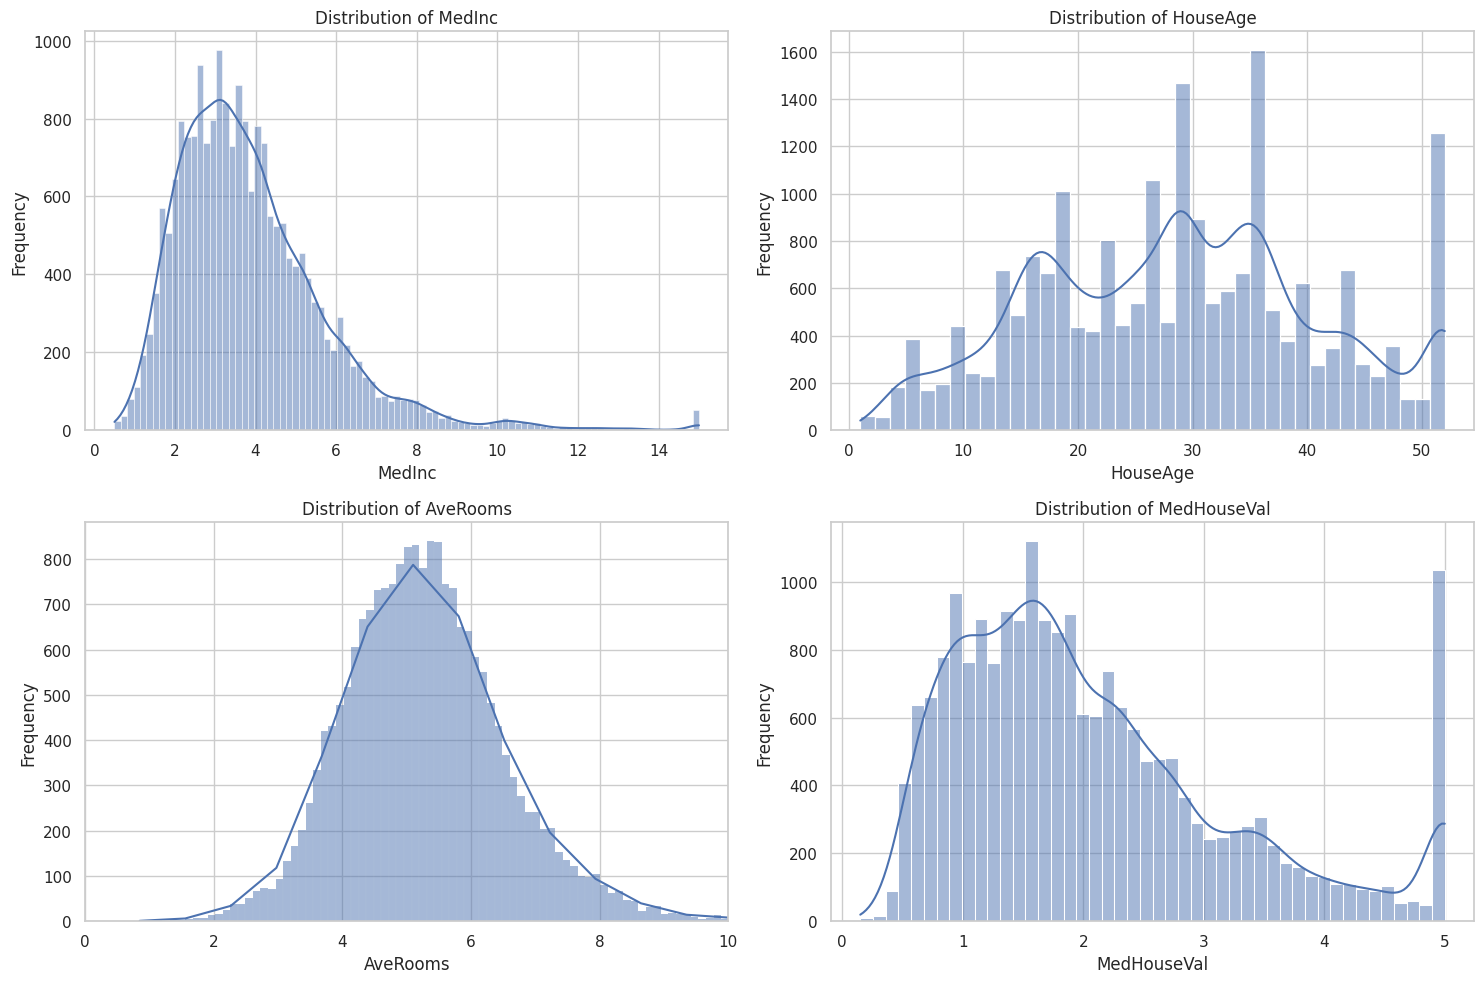

In [ ]:
# 20 Plot histograms for MedInc, HouseAge, AveRooms, and MedHouseValue. Interpret distributions
cols_to_plot = ['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color=PRIMARY_COLOR)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    if col == 'AveRooms':
      axes[i].set_xlim(0, 10)

plt.tight_layout()
plt.show()

Interpretation of distributions:
- MedInc is right-skewed (skewness ≈ 0.74): most districts have low-to-moderate income, with a
  long tail of high-income areas.
- HouseAge is fairly symmetric (skewness ≈ 0.06) but shows a sharp spike at 52 years, because the
  dataset top-codes house age — any house older than 52 is recorded as exactly 52.
- AveRooms is extremely right-skewed (skewness ≈ 20.7) due to a few districts with unusually high
  average room counts, far beyond the typical 4–7 range.
- MedHouseVal also shows a spike at its maximum (5.00001, i.e. $500,000), since the target itself
  is top-coded in the original 1990 census — a known limitation of this dataset.

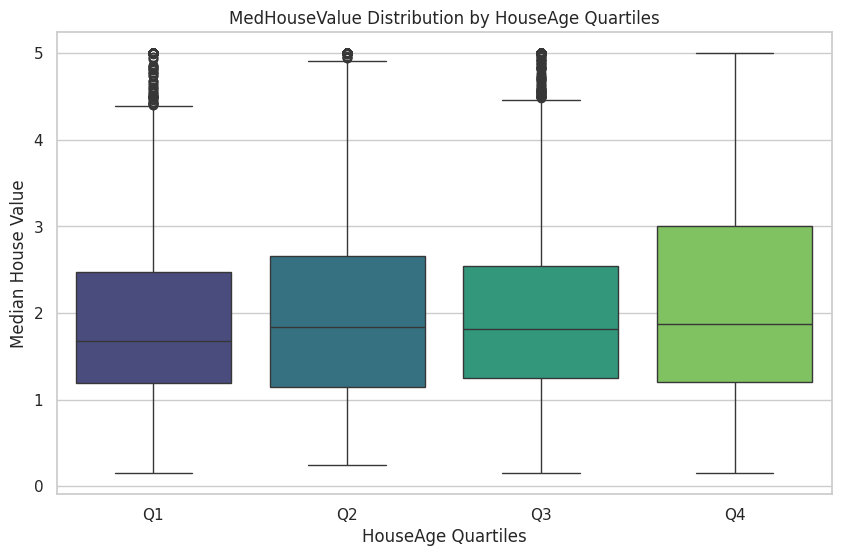

In [ ]:
# 21 Plot boxplots of MedHouseValue grouped by HouseAge quartiles
df_clean['HouseAgeQuartile'] = pd.qcut(df_clean['HouseAge'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
plt.figure(figsize=(10, 6))
sns.boxplot(x='HouseAgeQuartile', y='MedHouseVal', data=df_clean, palette=CATEGORICAL_PALETTE, hue='HouseAgeQuartile', legend=False)
plt.title('MedHouseValue Distribution by HouseAge Quartiles')
plt.xlabel('HouseAge Quartiles')
plt.ylabel('Median House Value')
plt.show()

In [ ]:
# 22 Identify which feature shows the largest spread across all samples.
df_numeric_only = df_clean.select_dtypes(include=[np.number])
variance_results = df_numeric_only.var()
largest_var_col = variance_results.idxmax()
largest_var_val = variance_results.max()
print(f"Largest spread feature by variance: {largest_var_col} value: {largest_var_val:.4f}")

Largest spread feature by variance: Population value: 1282470.4572


# Part 7: Visualization 2 — Bivariate

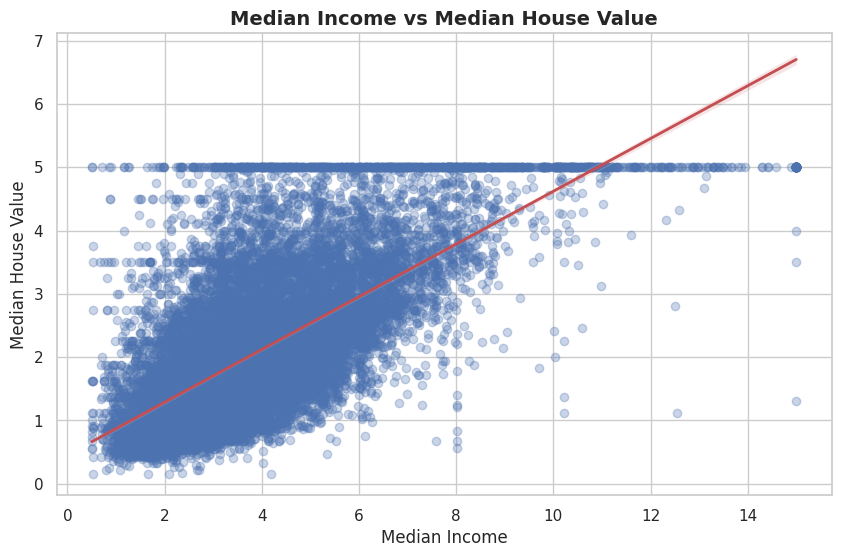

In [ ]:
# 23 .Scatter plot MedInc vs. MedHouseValue. Add regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='MedInc', y='MedHouseVal', data=df_clean,
            scatter_kws={'alpha': 0.3, 'color': PRIMARY_COLOR},
            line_kws={'color': SECONDARY_COLOR, 'linewidth': 2})

plt.title('Median Income vs Median House Value', fontsize=14, fontweight='bold')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.show()

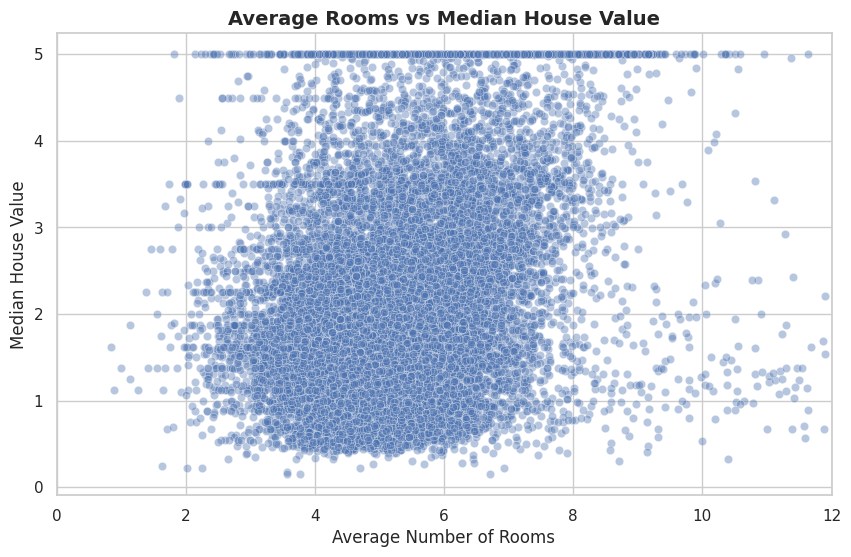

In [ ]:
# 24 Scatter plot AveRooms vs. MedHouseValue. What pattern do you see?
plt.figure(figsize=(10, 6))
sns.scatterplot(x='AveRooms', y='MedHouseVal', data=df_clean, alpha=0.4, color=PRIMARY_COLOR)
plt.xlim(0, 12)

plt.title('Average Rooms vs Median House Value', fontsize=14, fontweight='bold')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Value')
plt.show()

Pattern observed:
There is only a weak-to-moderate positive relationship between AveRooms and
MedHouseVal  much weaker and noisier than the MedInc relationship. House
values increase slightly as AveRooms grows in the typical 3–8 room range, plus a visible horizontal cap at MedHouseVal = 5.0
caused by the target's top-coding.

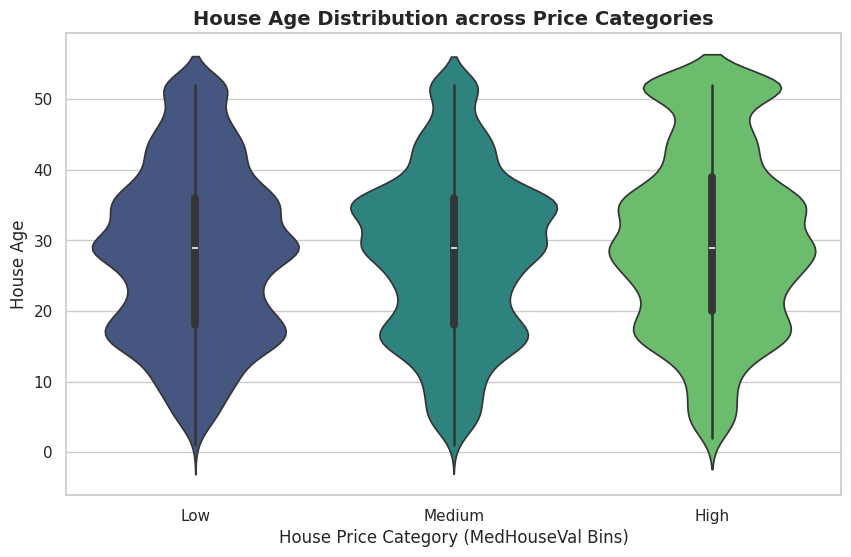

In [ ]:
# 25 Violin plot for HouseAge across bins of MedHouseValue (Low/Medium/High).
df_clean['Price_Category'] = pd.qcut(df_clean['MedHouseVal'], q=3, labels=['Low', 'Medium', 'High'])

plt.figure(figsize=(10, 6))
sns.violinplot(x='Price_Category', y='HouseAge', data=df_clean, palette=CATEGORICAL_PALETTE, hue='Price_Category', legend=False)

plt.title('House Age Distribution across Price Categories', fontsize=14, fontweight='bold')
plt.xlabel('House Price Category (MedHouseVal Bins)')
plt.ylabel('House Age')
plt.show()

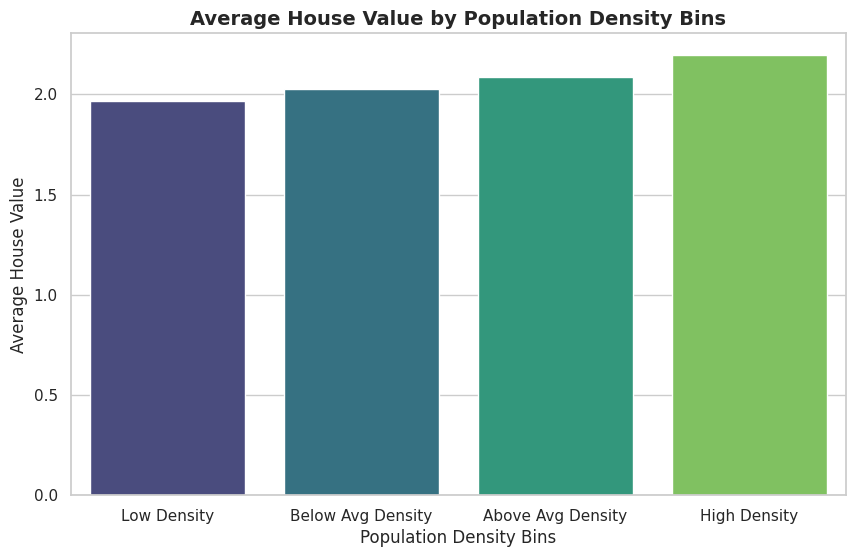

In [ ]:
# 26 Grouped bar chart: PopulationDensity bins vs. Average House Value
df_clean['PopDensity_Bins'] = pd.qcut(df_clean['PopulationDensity'], q=4, labels=['Low Density', 'Below Avg Density', 'Above Avg Density', 'High Density'])

density_grouped = df_clean.groupby('PopDensity_Bins', observed=False)['MedHouseVal'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='PopDensity_Bins', y='MedHouseVal', data=density_grouped, palette=CATEGORICAL_PALETTE, hue='PopDensity_Bins', legend=False)

plt.title('Average House Value by Population Density Bins', fontsize=14, fontweight='bold')
plt.xlabel('Population Density Bins')
plt.ylabel('Average House Value')
plt.show()

# Part 8: Visualization 3 — Multivariate & Advanced

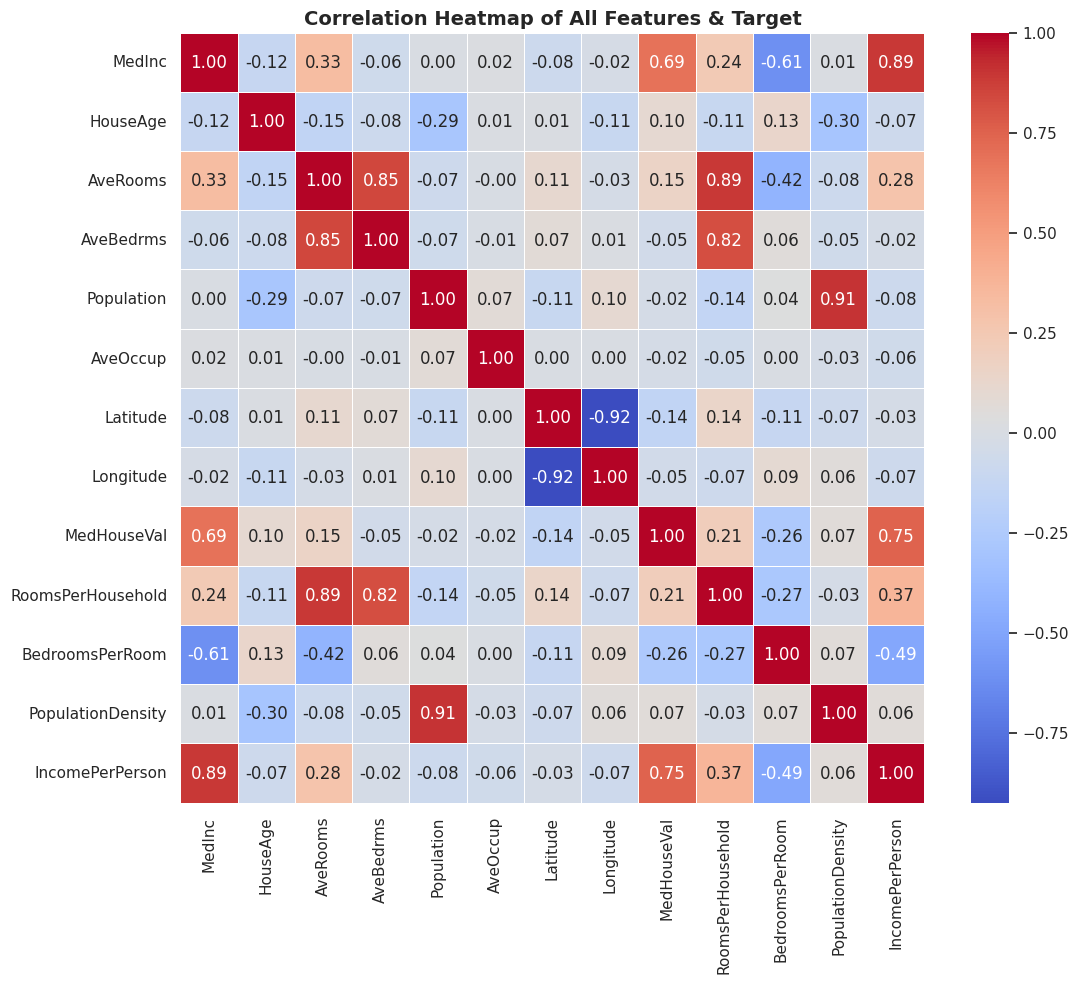

Top 2 Strongest Correlations with Target (MedHouseVal) 
1. IncomePerPerson: Correlation = 0.7456
2. MedInc: Correlation = 0.6867


In [ ]:
# 27 Correlation heatmap of all features and target. Highlight strongest 2 correlations
plt.figure(figsize=(12, 10))

numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True,cmap=CONTINUOUS_CMAP, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of All Features & Target', fontsize=14, fontweight='bold')
plt.show()

target_corr = corr_matrix['MedHouseVal'].drop('MedHouseVal').abs().sort_values(ascending=False)
strongest_1 = target_corr.index[0]
strongest_2 = target_corr.index[1]

print("Top 2 Strongest Correlations with Target (MedHouseVal) ")
print(f"1. {strongest_1}: Correlation = {corr_matrix['MedHouseVal'][strongest_1]:.4f}")
print(f"2. {strongest_2}: Correlation = {corr_matrix['MedHouseVal'][strongest_2]:.4f}")

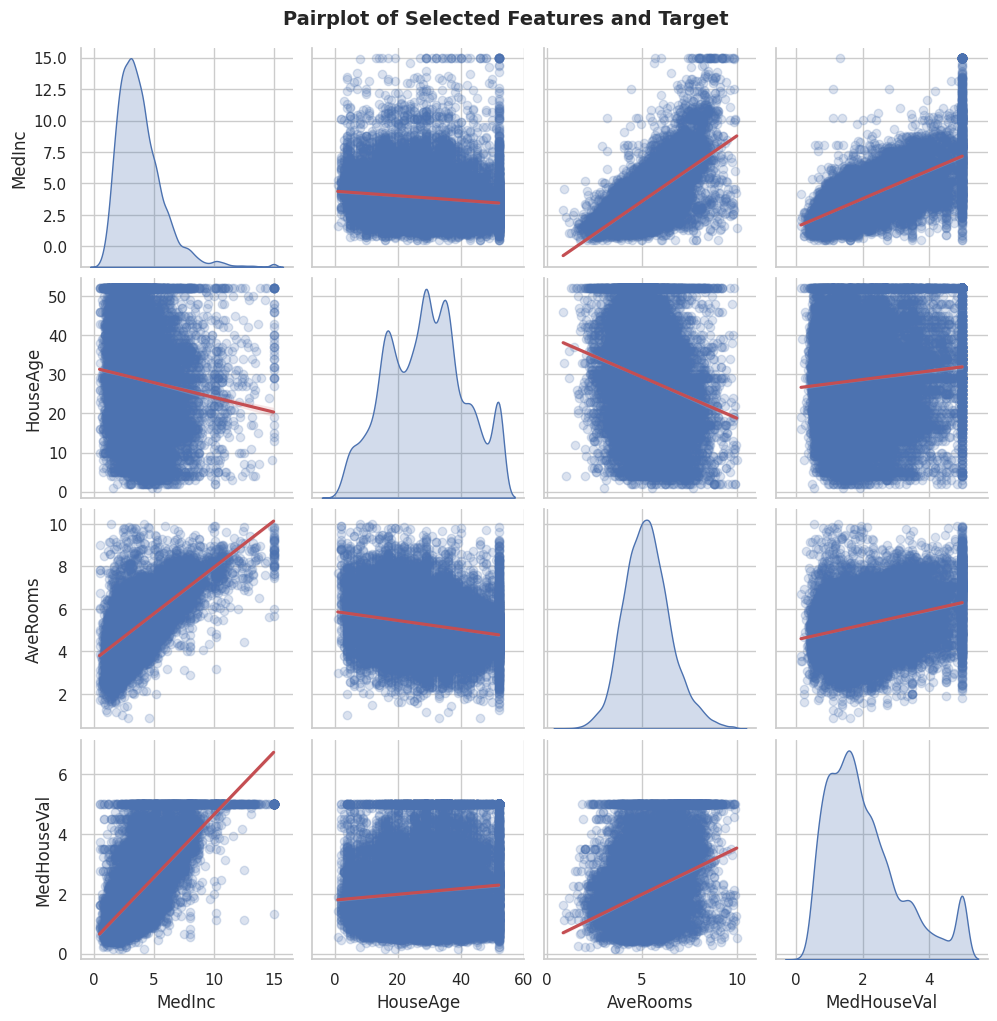

In [ ]:
# 28 Pairplot (seaborn) for MedInc, HouseAge, AveRooms, and MedHouseValue
selected_cols = ['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal']

df_pairplot = df_clean[selected_cols].copy()
df_pairplot = df_pairplot[df_pairplot['AveRooms'] <= 10]

sns.pairplot(
    df_pairplot,
    kind='reg',
    diag_kind='kde',
    plot_kws={
        'line_kws': {'color': SECONDARY_COLOR},
        'scatter_kws': {'alpha': 0.2, 'color': PRIMARY_COLOR}
    }
)

plt.suptitle('Pairplot of Selected Features and Target', y=1.02, fontsize=14, fontweight='bold')
plt.show()

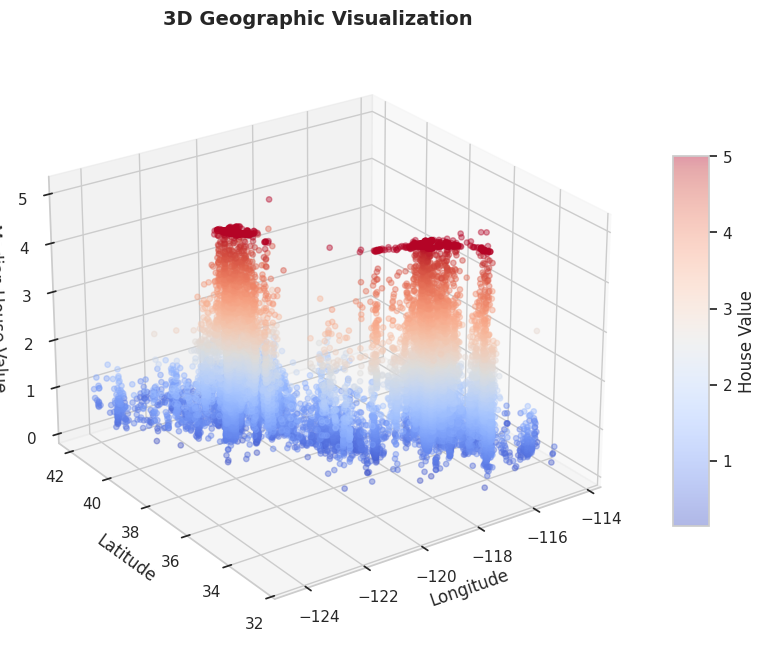

In [ ]:
# 29 3D scatter plot of (Longitude, Latitude, MedHouseValue). Discuss geographic trends
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(df_clean['Longitude'], df_clean['Latitude'], df_clean['MedHouseVal'],
                c=df_clean['MedHouseVal'], cmap=CONTINUOUS_CMAP, alpha=0.4, s=15)

ax.set_title('3D Geographic Visualization', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Median House Value')

fig.colorbar(sc, ax=ax, label='House Value', shrink=0.6, aspect=10)

ax.view_init(elev=25, azim=-125)
plt.show()

Geographic trends: Two distinct high-value clusters appear: one around the San Francisco Bay
Area (Longitude ≈ -122, Latitude ≈ 37–38) and one along coastal Southern California / Los Angeles
(Longitude ≈ -118, Latitude ≈ 33–34). Inland districts (less negative longitude) are consistently
cheaper regardless of latitude. This shows that proximity to the coast is at least as important a
price driver as Latitude alone — explaining why the simple Latitude correlation only
captures part of the geographic effect (the North-South component), while the 3D view reveals the
East-West coastal effect too.

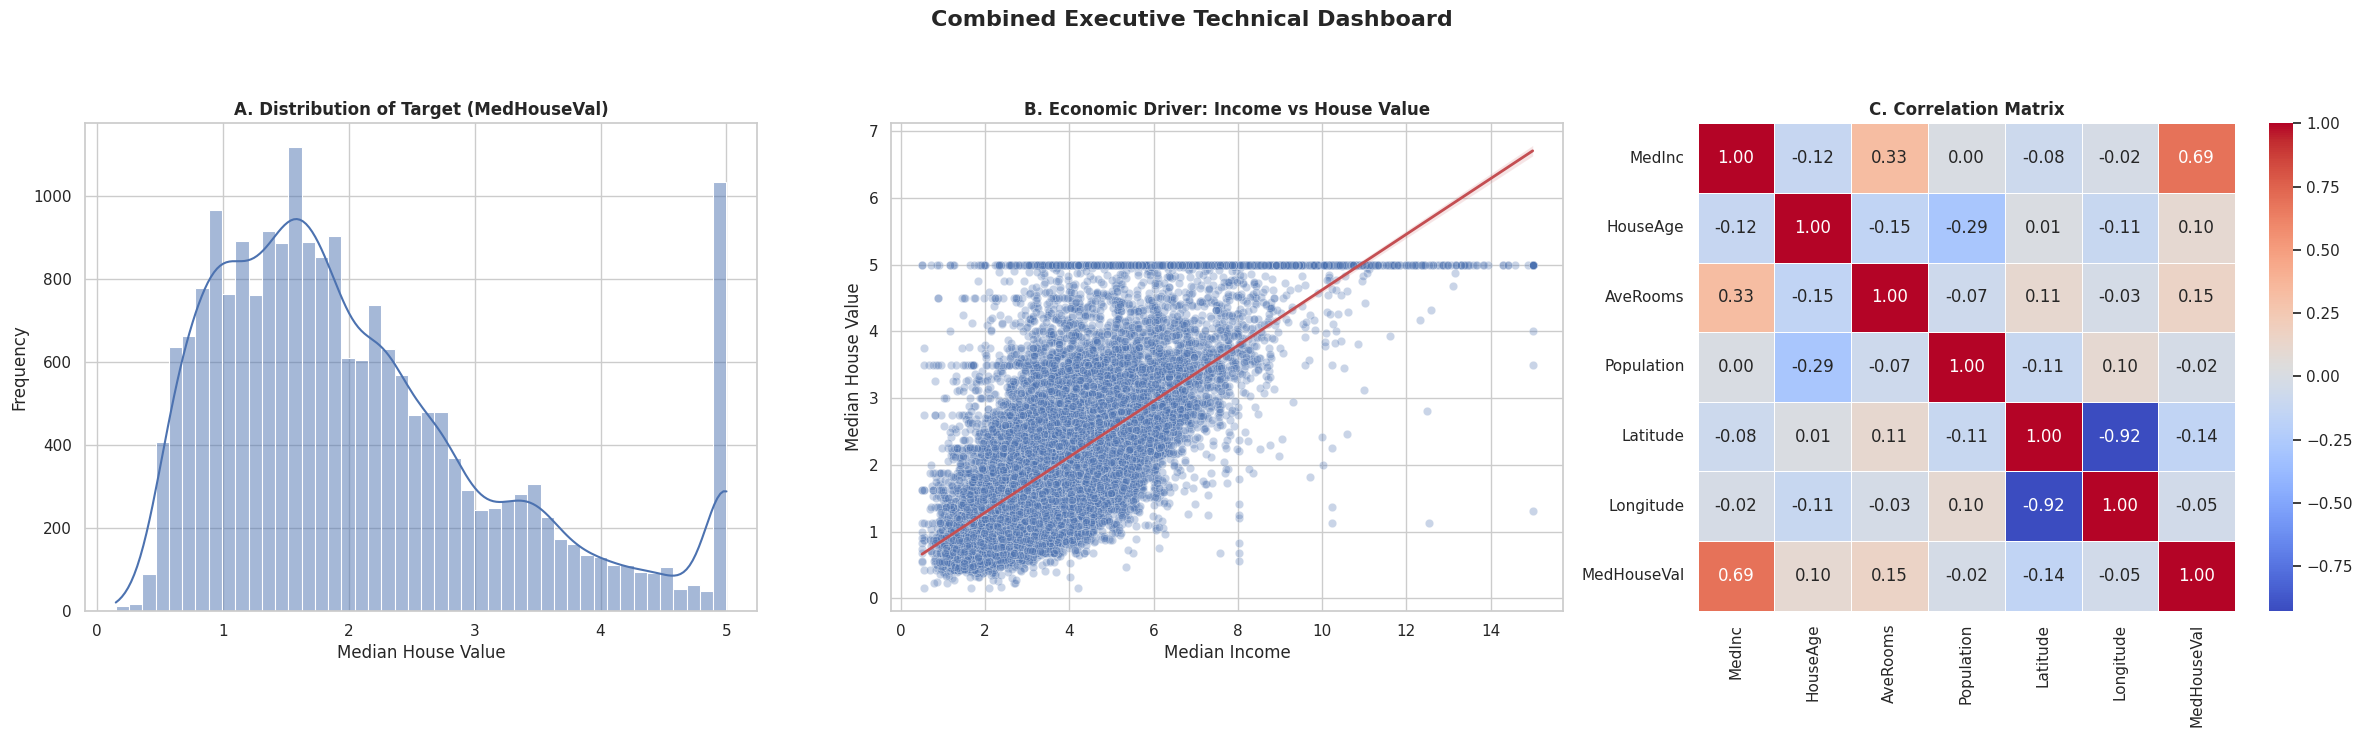

In [ ]:
# 30 Create a combined subplot figure (1 row, 3 columns)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Combined Executive Technical Dashboard', fontsize=16, fontweight='bold', y=1.05)

sns.histplot(df_clean['MedHouseVal'], kde=True, ax=axes[0], color=PRIMARY_COLOR)
axes[0].set_title('A. Distribution of Target (MedHouseVal)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Median House Value')
axes[0].set_ylabel('Frequency')


sns.scatterplot(x='MedInc', y='MedHouseVal', data=df_clean, alpha=0.3, ax=axes[1], color=PRIMARY_COLOR)
sns.regplot(x='MedInc', y='MedHouseVal', data=df_clean, scatter=False, ax=axes[1], color=SECONDARY_COLOR, line_kws={'linewidth': 2})
axes[1].set_title('B. Economic Driver: Income vs House Value', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Median Income')
axes[1].set_ylabel('Median House Value')

core_features = ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'Latitude', 'Longitude', 'MedHouseVal']
numeric_core = df_clean[core_features].select_dtypes(include=[np.number])
corr_matrix_core = numeric_core.corr()

sns.heatmap(corr_matrix_core, annot=True, cmap=CONTINUOUS_CMAP, fmt=".2f", ax=axes[2], cbar=True, linewidths=0.5)
axes[2].set_title('C. Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Part 9: Hard Analysis Questions

In [ ]:
# 31 Which 3 features best explain variations in MedHouseValue? Justify with variance and correlation analysis
full_corr = df_clean.select_dtypes(include=[np.number]).corr()
target_corr_full = full_corr['MedHouseVal'].drop('MedHouseVal').abs().sort_values(ascending=False)

print("Top 3 Features Explaining MedHouseValue Variations")
for i in range(3):
    feature = target_corr_full.index[i]
    corr_val = full_corr['MedHouseVal'][feature]
    var_val = variance_vals[feature]
    print(f"{i+1}. '{feature}'  Correlation: {corr_val:.4f}  Variance: {var_val:.4f}")

Top 3 Features Explaining MedHouseValue Variations
1. 'IncomePerPerson'  Correlation: 0.7456  Variance: 0.5701
2. 'MedInc'  Correlation: 0.6867  Variance: 3.6166
3. 'BedroomsPerRoom'  Correlation: -0.2556  Variance: 0.0034


In [ ]:
# 32 Compute within-group variance of MedHouseValue for HouseAge quartiles. Which group is most consistent?
within_var_age = df_clean.groupby('HouseAgeQuartile', observed=False)['MedHouseVal'].var()

print("Within-Group Variance for HouseAge Quartiles")
print(within_var_age.round(4))

most_consistent_age = within_var_age.idxmin()
print(f"\nThe most consistent group is: '{most_consistent_age}' with a variance of {within_var_age.min():.4f}")

Within-Group Variance for HouseAge Quartiles
HouseAgeQuartile
Q1    1.0265
Q2    1.3331
Q3    1.3083
Q4    1.6668
Name: MedHouseVal, dtype: float64

The most consistent group is: 'Q1' with a variance of 1.0265


In [ ]:
# 33 Compute between-group variance of MedHouseValue across income quartiles. Which groups differ the most?
group_means = df_clean.groupby('IncomeQuartile', observed=False)['MedHouseVal'].mean()
grand_mean = df_clean['MedHouseVal'].mean()
group_counts = df_clean.groupby('IncomeQuartile', observed=False)['MedHouseVal'].count()

n_samples = len(df_clean)
n_groups = len(group_means)
ss_between = sum(group_counts[g] * (group_means[g] - grand_mean)**2 for g in group_means.index)
between_variance = ss_between / (n_groups - 1)

print("Mean MedHouseValue per Income Quartile")
for quartile, mean_val in group_means.items():
    print(f"{quartile}: Mean Price = {mean_val:.4f}")

print(f"\nCalculated Between-Group Variance: {between_variance:.4f}")

max_diff_group1 = group_means.idxmin()
max_diff_group2 = group_means.idxmax()
max_diff_value = group_means.max() - group_means.min()

print(f"\nThe groups that differ the most are: '{max_diff_group1}' and '{max_diff_group2}'")
print(f"Absolute Difference in Means: {max_diff_value:.4f}")

Mean MedHouseValue per Income Quartile
Q1: Mean Price = 1.2301
Q2: Mean Price = 1.7186
Q3: Mean Price = 2.1594
Q4: Mean Price = 3.1661

Calculated Between-Group Variance: 3505.9875

The groups that differ the most are: 'Q1' and 'Q4'
Absolute Difference in Means: 1.9360


In [ ]:
# 34 Using standardized features, calculate the Mahalanobis distancebetween high-income and low-income neighborhoods (define bins). Interpret the result

features_for_mahalanobis = ['MedInc', 'HouseAge', 'AveRooms', 'Population', 'Latitude', 'Longitude']

low_income_data = df_clean[df_clean['IncomeQuartile'] == 'Q1'][features_for_mahalanobis]
high_income_data = df_clean[df_clean['IncomeQuartile'] == 'Q4'][features_for_mahalanobis]

mean_q1 = low_income_data.mean().values
mean_q4 = high_income_data.mean().values

pooled_covariance = df_clean[features_for_mahalanobis].cov()
inv_covariance_matrix = np.linalg.inv(pooled_covariance)

mahalanobis_dist = mahalanobis(mean_q1, mean_q4, inv_covariance_matrix)

print("Multivariate Mahalanobis Distance")
print(f"Calculated Mahalanobis Distance between Q1 and Q4: {mahalanobis_dist:.4f}")

Multivariate Mahalanobis Distance
Calculated Mahalanobis Distance between Q1 and Q4: 2.3544


# Part 10: Final Report
### 35 Answer your initial 3 hypotheses from Part 1
**H1: "Median income is positively associated with median house value."**
Confirmed. MedInc shows a strong positive correlation with MedHouseVal (r = 0.6867), and the
engineered IncomePerPerson feature correlates even more strongly (r = 0.7456). Average house
value rises monotonically across income quartiles, from $123,010 (Q1) to $316,610 (Q4) — a
~157% increase from the lowest to the highest income group.

**H2: "House values differ significantly across income quartiles."**
Confirmed. The between-group mean square (MSB) across income quartiles is 3505.99, and the gap
between the lowest (Q1) and highest (Q4) quartile means is $193,600. This is a substantial,
practically significant difference, not just a statistical artifact.

**H3: "Geographical location influences house values across California districts."**
Confirmed, but with an important nuance. A simple North vs. South split (using median Latitude)
shows only a modest difference (South median = $190,700 vs. North = $161,200), and Latitude
alone correlates weakly with price (r = -0.1442). However, the 3D scatter (Longitude, Latitude,
MedHouseVal) reveals the real driver: house values cluster strongly around the San Francisco Bay
Area and coastal Southern California, while inland districts are cheaper regardless of latitude.
So location matters, but as coastal proximity (a 2D effect), not a simple linear North-South trend.
### 36 Provide at least 3 key insights supported by evidence

1. **Per-capita income predicts price better than household income.** IncomePerPerson
   (MedInc / AveOccup) correlates more strongly with MedHouseVal (r = 0.7456) than raw MedInc
   (r = 0.6867). This suggests how income is distributed among household members matters as
   much as the income figure itself.

2. **House age doesn't drive price directly, but it amplifies uncertainty.** HouseAge has a weak
   direct correlation with price (r = 0.1018), yet within-group variance analysis shows the
   youngest homes (Q1) are the most price-consistent (variance = 1.0265), while the oldest homes
   (Q4) have the most price variability (variance = 1.6668) — meaning age widens the *range* of
   possible prices more than it shifts the average.

3. **High variance does not imply predictive power.** Population has by far the largest raw
   variance among all features (1,282,470), yet its correlation with MedHouseVal is essentially
   zero (r = -0.0246). This confirms a key distinction from Part 4: variance measures spread,
   not relevance to the target — a feature can vary enormously across California without
   explaining house prices at all.

4. **Income and location groups are statistically well-separated.** The
   Mahalanobis distance between low-income (Q1) and high-income (Q4) neighborhoods, computed
   across 6 standardized features simultaneously, is 2.35 — confirming these are genuinely
   distinct multivariate clusters, not just different on income alone.
### 37 Discuss limitations of the dataset (e.g., old data, missing socioeconomic features)

- **Outdated data**: the dataset reflects the 1990 U.S. Census, over three decades old; it does
  not capture current California housing dynamics (post-2008 crash, recent tech-driven price
  surges, remote-work migration patterns).
- **Top-coding**: both HouseAge (capped at 52) and MedHouseVal (capped at $500,000) are
  artificially truncated at their upper bounds, visibly causing spikes in their histograms
  (Part 6) — this compresses real variation at the high end and likely understates true
  correlations involving these variables.
- **No direct socioeconomic features**: the dataset lacks crime rate, school quality, employment
  rate, or walkability — all known major drivers of real estate prices that this analysis
  cannot account for.
- **Aggregated block-group data**: features like AveRooms and AveOccup are block-level averages,
  not individual household records, which can mask within-block heterogeneity.
### 38 Suggest future work

- Incorporate external datasets: crime statistics, school district ratings, employment/
  unemployment rates, and public transit access, joined by geographic location.
- Replace the raw Latitude/Longitude pair with an engineered "distance to coast" or
  "distance to nearest major city" feature, since the 3D analysis suggests coastal proximity
  matters more than latitude alone.
- Refresh the analysis with recent ACS (American Community Survey) data instead of the 1990
  census to reflect the current market.
- Move beyond exploratory analysis to a predictive model
  and evaluate it with proper train/test splits.

# Bonus

In [ ]:
# Write a Python function that automatically: Prints missing values per column & Detects outliers per feature & Summarizes skewness & kurtosis
def auto_eda_report(dataframe, z_thresh=3):
    """
    Automated EDA summary: missing values per column, outlier counts per feature
    (Z-score method), and skewness/kurtosis for all numeric columns.
    """
    numeric_df = dataframe.select_dtypes(include=[np.number])

    print("\n1. MISSING VALUES PER COLUMN\n")
    missing = dataframe.isnull().sum()
    missing_pct = (missing / len(dataframe) * 100).round(2)
    missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
    print(missing_report[missing_report['Missing Count'] > 0]
          if missing.sum() > 0 else "No missing values found.")

    print("\n2. OUTLIERS PER FEATURE (Z-score, threshold=3)\n")
    outlier_counts = {}
    for col in numeric_df.columns:
        col_data = numeric_df[col].dropna()
        z = np.abs((col_data - col_data.mean()) / col_data.std())
        outlier_counts[col] = int((z > z_thresh).sum())
    outlier_report = pd.Series(outlier_counts).sort_values(ascending=False)
    print(outlier_report)

    print("\n3. SKEWNESS & KURTOSIS\n")
    skew_kurt = pd.DataFrame({
        'Skewness': numeric_df.skew().round(4),
        'Kurtosis': numeric_df.kurt().round(4)
    })
    print(skew_kurt)

    return missing_report, outlier_report, skew_kurt

_ = auto_eda_report(df_clean)


1. MISSING VALUES PER COLUMN

No missing values found.

2. OUTLIERS PER FEATURE (Z-score, threshold=3)

PopulationDensity    363
MedInc               345
Population           342
IncomePerPerson      293
BedroomsPerRoom      284
AveBedrms            145
RoomsPerHousehold    139
AveRooms             133
AveOccup               8
HouseAge               0
MedHouseVal            0
Latitude               0
Longitude              0
dtype: int64

3. SKEWNESS & KURTOSIS

                   Skewness    Kurtosis
MedInc               1.6431      4.9232
HouseAge             0.0567     -0.6842
AveRooms            20.6979    879.3533
AveBedrms           31.3170   1636.7120
Population           4.9359     73.5531
AveOccup            97.6396  10651.0106
Latitude             0.4660     -1.1178
Longitude           -0.2978     -1.3302
MedHouseVal          0.9778      0.3279
RoomsPerHousehold   17.7751    600.6687
BedroomsPerRoom      2.2469     14.2807
PopulationDensity    3.4104     22.0580
IncomePerPer

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from sklearn.datasets import fetch_california_housing

# 1. Page Configuration
st.set_page_config(
    page_title="California Housing Dashboard",
    page_icon="🏠",
    layout="wide"
)

st.title(" California Housing Analysis & Interactive Dashboard ")
st.markdown("An interactive analytics dashboard to explore housing prices in California and their key influencing factors.")

# 2. Data Loading & Feature Engineering
@st.cache_data
def load_and_prep_data():
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame.copy()

    if 'MedHouseVal' in df.columns:
        df.rename(columns={'MedHouseVal': 'MedHouseValue'}, inplace=True)

    # Feature Engineering
    df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']
    df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']
    df['PopulationDensity'] = df['Population'] / df['AveOccup']
    df['IncomePerPerson'] = df['MedInc'] / df['AveOccup']

    # House Age Binning
    df['HouseAgeGroup'] = pd.cut(
        df['HouseAge'],
        bins=[0, 20, 40, 100],
        labels=['Young (<=20)', 'Middle (21-40)', 'Old (>40)']
    )

    return df

df_raw = load_and_prep_data()

# 3. Sidebar Filters
st.sidebar.header(" Filter Data ")

min_inc = float(df_raw['MedInc'].min())
max_inc = float(df_raw['MedInc'].max())
selected_inc = st.sidebar.slider(
    "Median Income Range (MedInc):",
    min_value=min_inc,
    max_value=max_inc,
    value=(min_inc, max_inc)
)

selected_age_groups = st.sidebar.multiselect(
    "House Age Category:",
    options=df_raw['HouseAgeGroup'].cat.categories.tolist(),
    default=df_raw['HouseAgeGroup'].cat.categories.tolist()
)

# Apply Filtering
df_filtered = df_raw[
    (df_raw['MedInc'] >= selected_inc[0]) &
    (df_raw['MedInc'] <= selected_inc[1]) &
    (df_raw['HouseAgeGroup'].isin(selected_age_groups))
].copy()

# 4. Key Performance Indicators (KPIs)
col1, col2, col3, col4 = st.columns(4)
col1.metric("Analyzed Districts", f"{len(df_filtered):,}")
col2.metric("Avg House Value ($100k)", f"${df_filtered['MedHouseValue'].mean():.2f}")
col3.metric("Avg Income ($10k)", f"${df_filtered['MedInc'].mean():.2f}")
col4.metric("Avg House Age", f"{df_filtered['HouseAge'].mean():.1f} yrs")

st.markdown("---")

# 5. Main Tabs
tab1, tab2, tab3 = st.tabs([" Geographic Map ", " Distributions & Relationships ", " Data Summary "])

#  Tab 1: Map
with tab1:
    st.subheader("Geographic Distribution of California Housing")
    st.markdown("**Interactive Map of California** *(Blue = Low House Value, Red = High House Value)*")

    if not df_filtered.empty:
        norm = Normalize(vmin=df_raw['MedHouseValue'].min(), vmax=df_raw['MedHouseValue'].max())
        cmap = plt.get_cmap('coolwarm')

        rgb_colors = (cmap(norm(df_filtered['MedHouseValue'].values))[:, :3] * 255).astype(int)
        hex_colors = [f"#{r:02x}{g:02x}{b:02x}" for r, g, b in rgb_colors]

        map_df = pd.DataFrame({
            'latitude': df_filtered['Latitude'],
            'longitude': df_filtered['Longitude'],
            'color': hex_colors
        })

        st.map(map_df, color='color', size=10)
    else:
        st.warning("No data available for the selected filters.")

#  Tab 2: Visualizations
with tab2:
    st.subheader("Feature Relationship Analysis")

    col_vis1, col_vis2 = st.columns(2)

    with col_vis1:
        st.write("#### Income vs. House Value")
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.scatterplot(
            data=df_filtered,
            x='MedInc',
            y='MedHouseValue',
            alpha=0.4,
            ax=ax,
            color='#4C72B0'
        )
        ax.set_title("MedInc vs MedHouseValue")
        ax.set_xlabel("Median Income ($10,000s)")
        ax.set_ylabel("Median House Value ($100,000s)")
        st.pyplot(fig)

    with col_vis2:
        st.write("#### Correlation Matrix")

        all_features = [
            'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
            'Latitude', 'Longitude', 'RoomsPerHousehold', 'BedroomsPerRoom',
            'PopulationDensity', 'IncomePerPerson', 'MedHouseValue'
        ]

        corr_df = df_filtered[all_features].corr()

        fig, ax = plt.subplots(figsize=(11, 9))

        sns.heatmap(
            corr_df,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            ax=ax,
            cbar=True,
            annot_kws={"size": 7},
            linewidths=0.5
        )
        ax.set_title("Feature Correlation Heatmap", fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        st.pyplot(fig)

#  Tab 3: Data Summary
with tab3:
    st.subheader("Filtered Dataset Preview")
    display_cols = [c for c in df_filtered.columns if not c.startswith('color_')]
    st.dataframe(df_filtered[display_cols].head(100), use_container_width=True)

    st.subheader("Descriptive Statistics")
    st.write(df_filtered[display_cols].describe().T)

Overwriting app.py


In [ ]:
!pip install pyngrok pydeck -q
from pyngrok import ngrok
from google.colab import userdata
import time

ngrok.kill()
!pkill -f streamlit
time.sleep(2)

ngrok_token = userdata.get('TOKEN')
ngrok.set_auth_token(ngrok_token)

!streamlit run app.py &>/content/logs.txt &
time.sleep(8)

!cat /content/logs.txt

public_url = ngrok.connect(8501)
print("Dashboard URL:", public_url)



2026-08-06 15:46:35.131 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.237.92.219:8501

Dashboard URL: NgrokTunnel: "https://effective-list-strict.ngrok-free.dev" -> "http://localhost:8501"
